In [76]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [36]:
import pandas as pd
from google.colab import drive

# Wczytanie oryginalnego pliku
df = pd.read_csv("/content/drive/MyDrive/Programowanie2/dataset.csv")

# Usunięcie spacji z nazw kolumn
df.columns = df.columns.str.strip()

# Kolumny z wartościami 1/2
columns_to_fix = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ANXIETY',
    'PEER_PRESSURE',
    'CHRONIC DISEASE',
    'FATIGUE',
    'ALLERGY',
    'WHEEZING',
    'ALCOHOL CONSUMING',
    'COUGHING',
    'SHORTNESS OF BREATH',
    'SWALLOWING DIFFICULTY',
    'CHEST PAIN'
]

# Zamiana 1 -> 0, 2 -> 1
for col in columns_to_fix:
    if col in df.columns:
        df[col] = df[col].replace({1: 0, 2: 1})

# Zamiana płci
df['GENDER'] = df['GENDER'].map({
    'M': 0,
    'F': 1
})

# Zamiana zmiennej docelowej
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({
    'NO': 0,
    'YES': 1
})

# Podgląd
print(df.head())

# Zapis nowego pliku
new_path = "/content/drive/MyDrive/Programowanie2/dataset_clean.csv"

df.to_csv(new_path, index=False)

print(f"\nZapisano plik:\n{new_path}")

   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       0   69        0               1        1              0   
1       0   74        1               0        0              0   
2       1   59        0               0        0              1   
3       0   63        1               1        1              0   
4       1   63        0               1        0              0   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                0        1        0         1                  1         1   
1                1        1        1         0                  0         0   
2                0        1        0         1                  0         1   
3                0        0        0         0                  1         0   
4                0        0        0         1                  0         1   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER  
0                    1                      1    

#Podstawowa analiza statystyczna

In [39]:
# Wywołanie
df.head()
df.info()
pd.set_option('display.max_rows', None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    int64
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    i

In [40]:
print(df["LUNG_CANCER"].value_counts())

LUNG_CANCER
1    270
0     39
Name: count, dtype: int64


In [41]:
df.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,0.475728,62.673139,0.563107,0.569579,0.498382,0.501618,0.504854,0.673139,0.556634,0.556634,0.556634,0.579288,0.640777,0.469256,0.556634,0.873786
std,0.500221,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588,0.332629
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,62.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,69.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,87.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


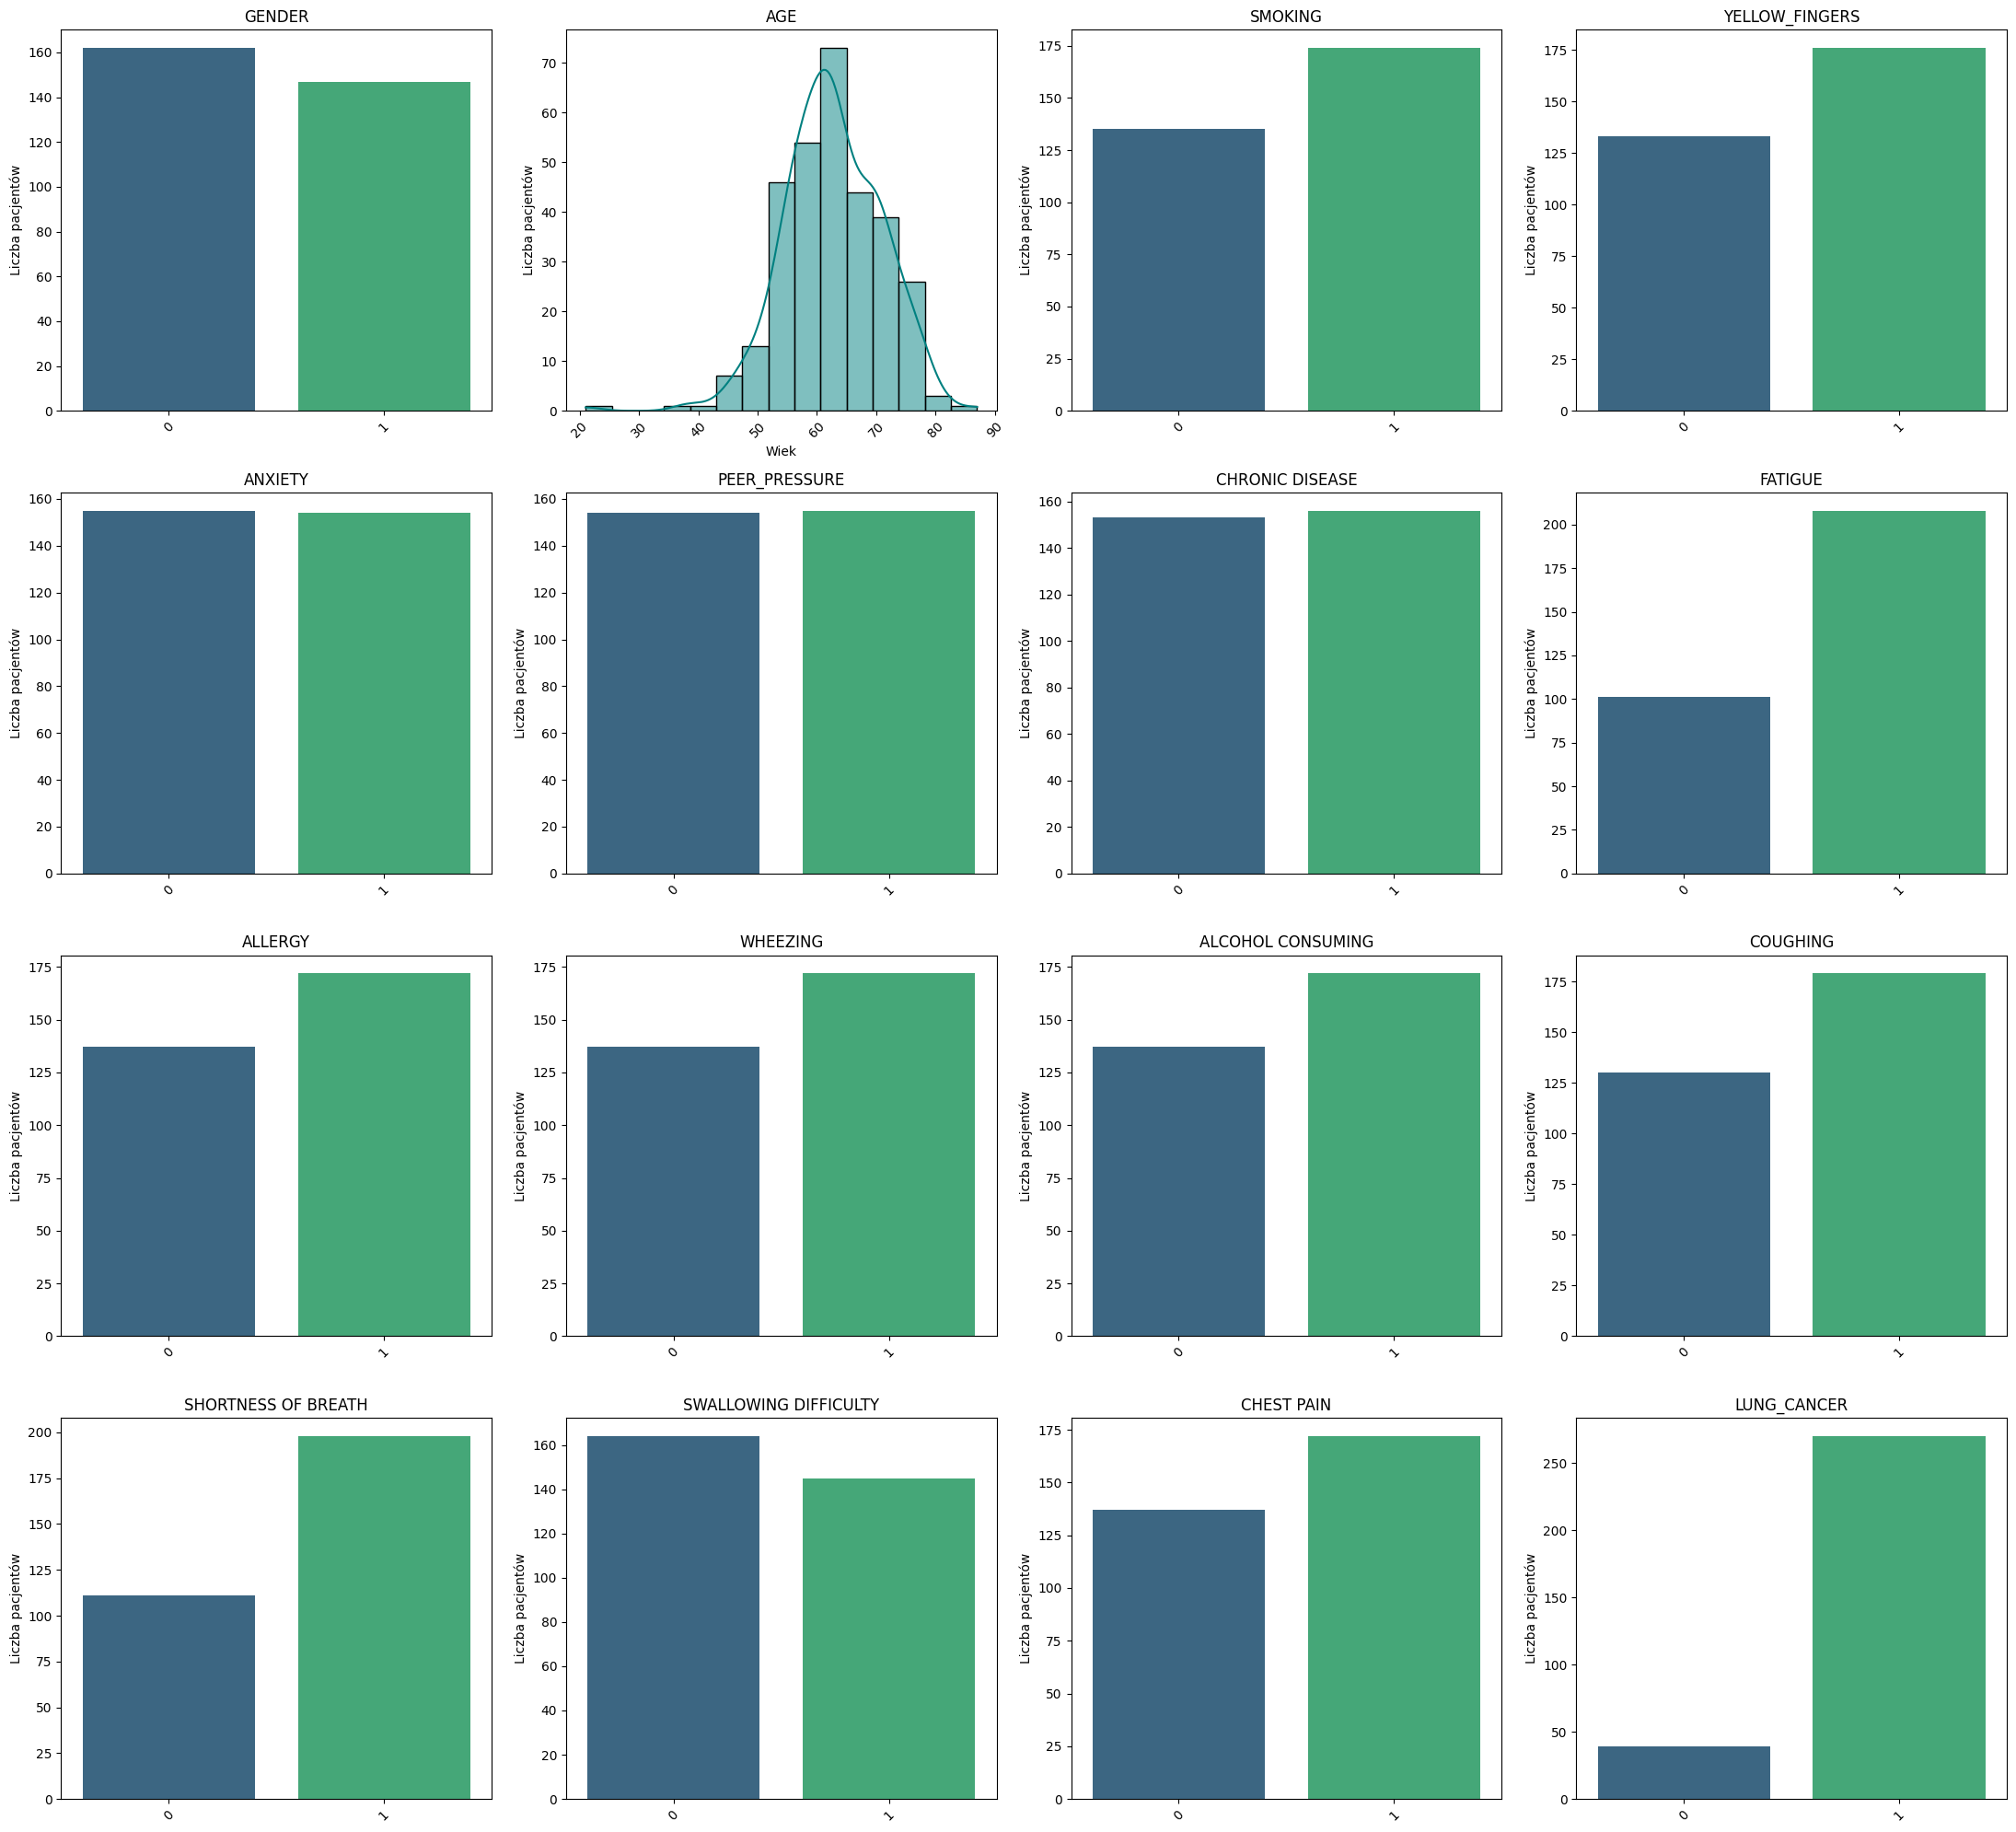

In [44]:
import math
n_cols = 4
n_rows = math.ceil(len(df.columns) / n_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 5 * n_rows))
axes = np.array(axes).flatten()

# Pętla po wszystkich kolumnach w dataset
for i, col in enumerate(df.columns):

    #AGE robiE histogram zamiast countplota (ze względu na nakładające się dane an siebie)
    if col == 'AGE':
        sns.histplot(data=df, x=col, ax=axes[i], kde=True, color="teal", bins=15)
        axes[i].set_title(f"AGE")
        axes[i].set_xlabel("Wiek")

    #Standardowy wykres słupkowy (1, 2, tekstowe)
    else:
        sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel("")

    axes[i].set_ylabel("Liczba pacjentów")

    #Obracanie napisów na osi X o 45 stopni
    axes[i].tick_params(axis='x', rotation=45)

# Ukrywam puste wykresy, gdy jest miejsce
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

#Odstępy między wykresami
plt.tight_layout()
plt.show()


#Train-test split

In [72]:
#Stratify zapewnia, że proporcje chorych i zdrowych pacjentów w zbiorach treningowym i testowym są identyczne jak w całym zbiorze.
#Używam go, aby uniknąć nierównowagi klasy
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Inicjalizacja podziału
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Wykonanie podziału (używamy kolumny LUNG_CANCER do stratyfikacji)
for train_index, test_index in split.split(df, df["LUNG_CANCER"]):
    strat_train_set = df.iloc[train_index]
    strat_test_set = df.iloc[test_index]

# 3. Weryfikacja proporcji (czy podział zachował balans klas?)
print("Proporcje w całym zbiorze:")
print(df["LUNG_CANCER"].value_counts() / len(df))
print("\nProporcje w zbiorze treningowym:")
print(strat_train_set["LUNG_CANCER"].value_counts() / len(strat_train_set))

# 4. Teraz pracujesz na zbiorze treningowym
df = strat_train_set.copy()

Proporcje w całym zbiorze:
LUNG_CANCER
1    0.873786
0    0.126214
Name: count, dtype: float64

Proporcje w zbiorze treningowym:
LUNG_CANCER
1    0.874494
0    0.125506
Name: count, dtype: float64


In [73]:
features = df.drop("LUNG_CANCER", axis=1)
labels = df["LUNG_CANCER"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify = labels
)

#Wizualizacje i korelacje

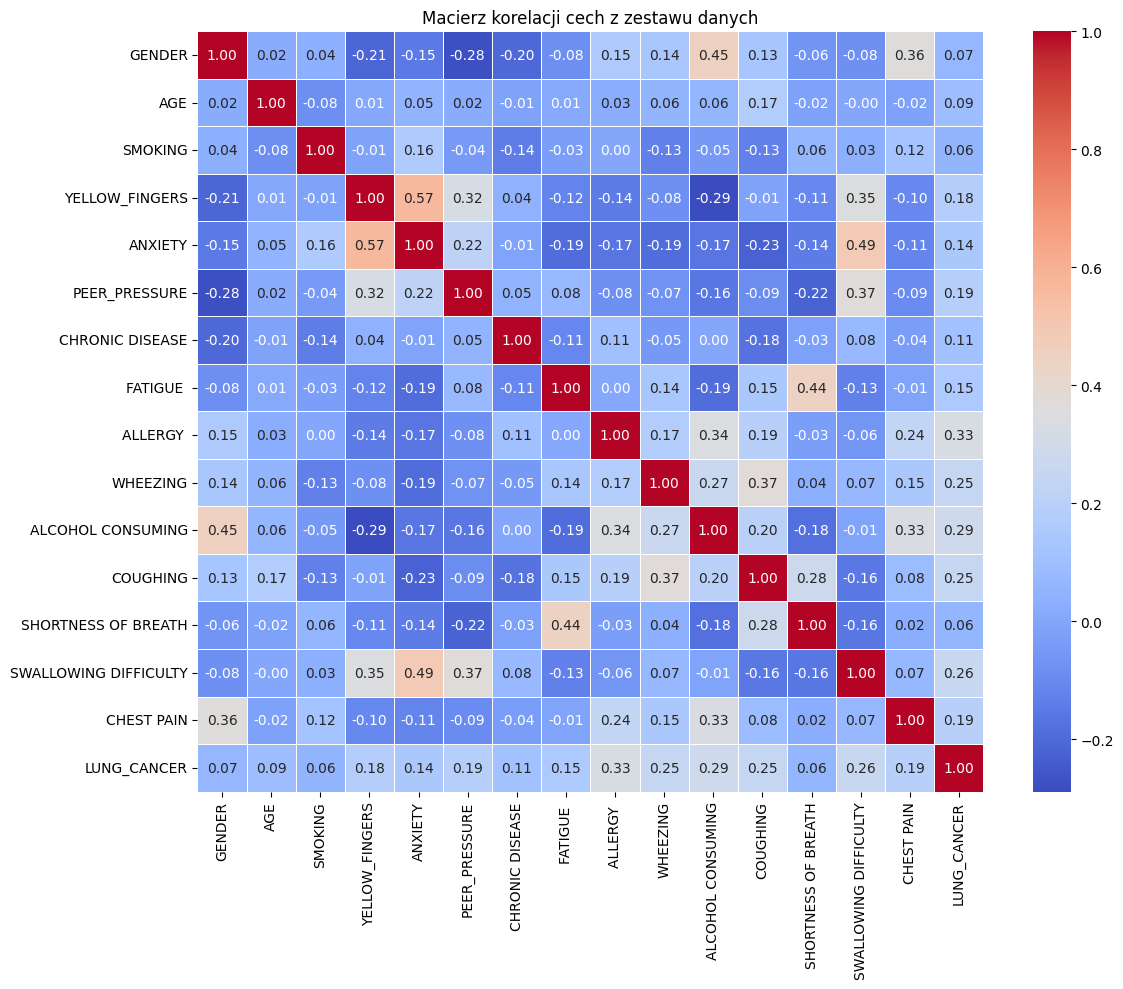

5 cech najsilniej powiązanych z LUNG_CANCER:
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
Name: LUNG_CANCER, dtype: float64


/tmp/ipykernel_4719/2110648101.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


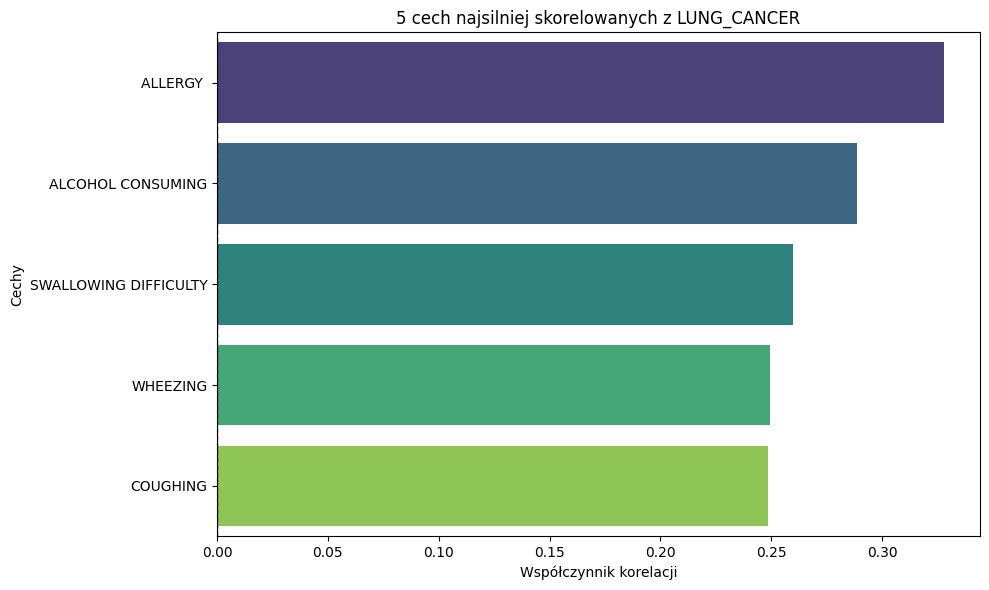

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
df.columns = df.columns.str.strip()

#Wczytanie danych
df = pd.read_csv("/content/drive/MyDrive/Programowanie2/dataset.csv")

#Mapowanie wartości tekstowych na liczbowe
df_encoded = df.copy()
df_encoded["GENDER"] = df_encoded["GENDER"].map({"M": 1, "F": 0})
df_encoded["LUNG_CANCER"] = df_encoded["LUNG_CANCER"].map({"YES": 1, "NO": 0})

#Macierz Korelacji
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()

#heatmap
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Macierz korelacji cech z zestawu danych")
plt.tight_layout()
plt.show()

#Korelacja z LUNG_CANCER, biorę wartość bezwzględną i sortuje malejąco
lung_cancer_corr = correlation_matrix["LUNG_CANCER"].drop("LUNG_CANCER")
top_5_features = lung_cancer_corr.abs().nlargest(5)

# Pobieram oryginalne wartości korelacji
top_5_corr_values = lung_cancer_corr[top_5_features.index]

print("5 cech najsilniej powiązanych z LUNG_CANCER:")
print(top_5_corr_values)

#Wykres słupkowy
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_5_corr_values.values, y=top_5_corr_values.index, palette="viridis"
)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Współczynnik korelacji")
plt.ylabel("Cechy")
plt.title("5 cech najsilniej skorelowanych z LUNG_CANCER")
plt.tight_layout()
plt.show()

In [86]:
# Wczytanie danych
df = load_lung_cancer_data()

# Tymczasowa kopia danych
df_numeric = df.copy()

# Zamiana zmiennych tekstowych na liczbowe
df_numeric['LUNG_CANCER'] = df_numeric['LUNG_CANCER'].map({
    'YES': 1,
    'NO': 0
})

df_numeric['GENDER'] = df_numeric['GENDER'].map({
    'M': 1,
    'F': 0
})

# Jeżeli nadal masz kolumny z wartościami 1 i 2
columns_to_fix = [
    'SMOKING',
    'YELLOW_FINGERS',
    'ANXIETY',
    'PEER_PRESSURE',
    'CHRONIC DISEASE',
    'FATIGUE',
    'ALLERGY',
    'WHEEZING',
    'ALCOHOL CONSUMING',
    'COUGHING',
    'SHORTNESS OF BREATH',
    'SWALLOWING DIFFICULTY',
    'CHEST PAIN'
]

for col in columns_to_fix:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].replace({1: 0, 2: 1})

# Obliczenie macierzy korelacji
corr_matrix = df_numeric.corr(numeric_only=True)

# Korelacje względem zmiennej docelowej
print(
    corr_matrix["LUNG_CANCER"]
    .sort_values(ascending=False)
)

LUNG_CANCER              1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
AGE                      0.089465
GENDER                   0.067254
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
Name: LUNG_CANCER, dtype: float64



Podstawowe informacje
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  

,count,mean,std,min,25%,50%,75%,max
AGE,309.0,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SMOKING,309.0,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,309.0,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
ANXIETY,309.0,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,309.0,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,309.0,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FATIGUE,309.0,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
ALLERGY,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WHEEZING,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0



Brakujące wartości
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

Macierz korelacji


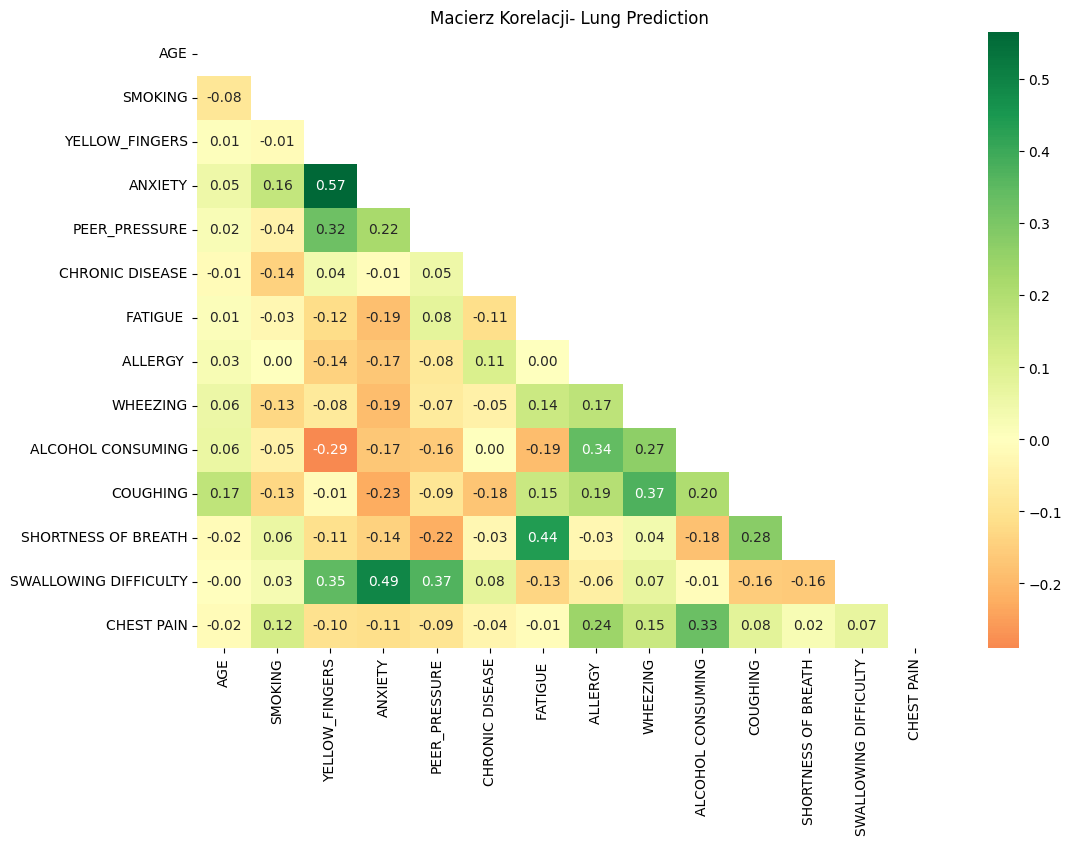

In [87]:
print("\nPodstawowe informacje")
print(df.info())

print("\nStatystyki opisowe")
display(df.describe().T)

print("\nBrakujące wartości")
print(df.isnull().sum())

print("\nMacierz korelacji")
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title('Macierz Korelacji- Lung Prediction')
plt.show()

In [88]:
#Wczytanie danych
df = load_lung_cancer_data()

# Mapowanie płci
df['GENDER'] = df['GENDER'].map({'M': 0, 'F': 1})

# Mapowanie etykiety
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

#Rozdzielanie na x i y
features = df.drop("LUNG_CANCER", axis=1).copy()
labels = df["LUNG_CANCER"].copy()

#Obliczanie korelacji
df_with_labels = features.copy()
df_with_labels["LUNG_CANCER"] = labels

corr_matrix = df_with_labels.corr()
print(corr_matrix["LUNG_CANCER"].sort_values(ascending=False))

LUNG_CANCER              1.000000
ALLERGY                  0.327766
ALCOHOL CONSUMING        0.288533
SWALLOWING DIFFICULTY    0.259730
WHEEZING                 0.249300
COUGHING                 0.248570
CHEST PAIN               0.190451
PEER_PRESSURE            0.186388
YELLOW_FINGERS           0.181339
FATIGUE                  0.150673
ANXIETY                  0.144947
CHRONIC DISEASE          0.110891
AGE                      0.089465
SHORTNESS OF BREATH      0.060738
SMOKING                  0.058179
GENDER                  -0.067254
Name: LUNG_CANCER, dtype: float64


#Data cleaning- pipeline

1. Przygotowanie klas pomocniczych

In [89]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer

# Klasa do wyboru kolumn
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names]

# Klasa do automatycznego zamieniania tekstu (M/F na liczby)
class CustomLabelEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Tworzę kopię
        X_copy = X.copy()
        for col in X_copy.columns:
            # Zamiana YES/NO na 1/0
            X_copy[col] = X_copy[col].replace({'YES': 1, 'NO': 0, 'M': 1, 'F': 0})
        return X_copy.values

2. Pipeline definition

In [58]:
num_attribs = ['AGE'] # Wiek jako liczba
cat_attribs = ['GENDER', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
               'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING',
               'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']

# Pipeline dla wieku
num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
])

# Pipeline dla reszty danych
cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('encoder', CustomLabelEncoder()),
    ('imputer', SimpleImputer(strategy="most_frequent")),
])

#Całość
full_pipeline = FeatureUnion(transformer_list=[
    ("num_pipeline", num_pipeline),
    ("cat_pipeline", cat_pipeline),
])

In [90]:
df = load_lung_cancer_data()

#usunięcie spacji z wszystkich kolumn
df.columns = df.columns.str.strip()

#mapowanie
df['GENDER'] = df['GENDER'].map({'M': 0, 'F': 1})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'NO': 0, 'YES': 1})

# Pętla do poprawy wartości 1 i 2 na 0 i 1
columns_to_fix = ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
                  'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
                  'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
                  'SWALLOWING DIFFICULTY', 'CHEST PAIN']

for col in columns_to_fix:
    # Upewniam się, że kolumna istnieje przed zmianą
    if col in df.columns:
        df[col] = df[col].replace({1: 0, 2: 1})

#Logistic Regression

In [91]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

#Klasa do inżynierii cech
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["smoking_effects"] = X["SMOKING"] + X["YELLOW_FINGERS"] + X["PEER_PRESSURE"]
        X["stress_index"] = X["ANXIETY"] + X["PEER_PRESSURE"]
        X["respiratory_score"] = X["COUGHING"] + X["WHEEZING"] + X["SHORTNESS OF BREATH"]
        return X

#Wczytywanie danych
le = LabelEncoder()
df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])
df['GENDER'] = le.fit_transform(df['GENDER'])

#Podział na X i y
X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
stratify = y

#Definicja Pipeline
pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()), # Nasza klasa
    ('scaler', StandardScaler()),            # Normalizacja
    ('classifier', LogisticRegression())     # Model
])

#trening i wyniki
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Dokładność modelu:", accuracy_score(y_test, y_pred))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred))

Dokładność modelu: 0.967741935483871

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62



#Random Forest Classifier

In [93]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('feature_engineer', FeatureEngineer()), # Nasza klasa inżynierii cech
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Trening
pipeline_rf.fit(X_train, y_train)

# Predykcja
y_pred_rf = pipeline_rf.predict(X_test)

# Wyniki
print("Dokładność modelu Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred_rf))

# Dostęp do ważności cech (feature_importances_)
#krok 'classifier'
rf_model = pipeline_rf.named_steps['classifier']
feature_names = pipeline_rf.named_steps['feature_engineer'].transform(X_train.copy()).columns

feature_importance = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': rf_model.feature_importances_
})

print("\nNajważniejsze cechy według Random Forest:")
print(feature_importance.sort_values(by='Ważność', ascending=False))

Dokładność modelu Random Forest: 0.967741935483871

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62


Najważniejsze cechy według Random Forest:
                    Cecha   Ważność
1                     AGE  0.174020
17      respiratory_score  0.083279
10      ALCOHOL CONSUMING  0.076426
16           stress_index  0.071752
15        smoking_effects  0.063646
8                 ALLERGY  0.063283
7                 FATIGUE  0.049463
13  SWALLOWING DIFFICULTY  0.048139
5           PEER_PRESSURE  0.044940
3          YELLOW_FINGERS  0.042101
14             CHEST PAIN  0.040034
6         CHRONIC DISEASE  0.040018
9                WHEEZING  0.039854
11               COUGHING  0.038035
0               

#XGBoost Classifier

In [94]:
from sklearn.model_selection import StratifiedShuffleSplit
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

#Definicja Pipeline
pipeline_xgb = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='logloss'
    ))
])

#Trening na surowych danych
pipeline_xgb.fit(X_train, y_train)

#Predykcja
y_pred_xgb = pipeline_xgb.predict(X_test)

#Wyniki i Raport
print("XGBoost Classifier")
print("Dokładność modelu:", accuracy_score(y_test, y_pred_xgb))
print("\nRaport klasyfikacji:\n")
print(classification_report(y_test, y_pred_xgb))

#Ważność cech
#krok feature_engineer
temp_data = pipeline_xgb.named_steps['feature_engineer'].transform(X_train)
xgb_model = pipeline_xgb.named_steps['classifier']

feature_importance_xgb = pd.DataFrame({
    'Cecha': temp_data.columns,
    'Ważność': xgb_model.feature_importances_
})

print("\nNajważniejsze cechy według XGBoost:")
print(feature_importance_xgb.sort_values(by='Ważność', ascending=False))

XGBoost Classifier
Dokładność modelu: 0.967741935483871

Raport klasyfikacji:

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62


Najważniejsze cechy według XGBoost:
                    Cecha   Ważność
13  SWALLOWING DIFFICULTY  0.142892
8                 ALLERGY  0.133486
5           PEER_PRESSURE  0.130677
10      ALCOHOL CONSUMING  0.104419
16           stress_index  0.086179
4                 ANXIETY  0.064860
17      respiratory_score  0.063811
15        smoking_effects  0.043865
7                 FATIGUE  0.038609
6         CHRONIC DISEASE  0.033670
11               COUGHING  0.032340
0                  GENDER  0.027680
14             CHEST PAIN  0.022173
1                     AGE  0.018342
9                

#Wizualizacja macierzy i pomyłek

--- Regresja Logistyczna ---
Dokładność: 0.97
--- Random Forest ---
Dokładność: 0.97
--- XGBoost ---
Dokładność: 0.97


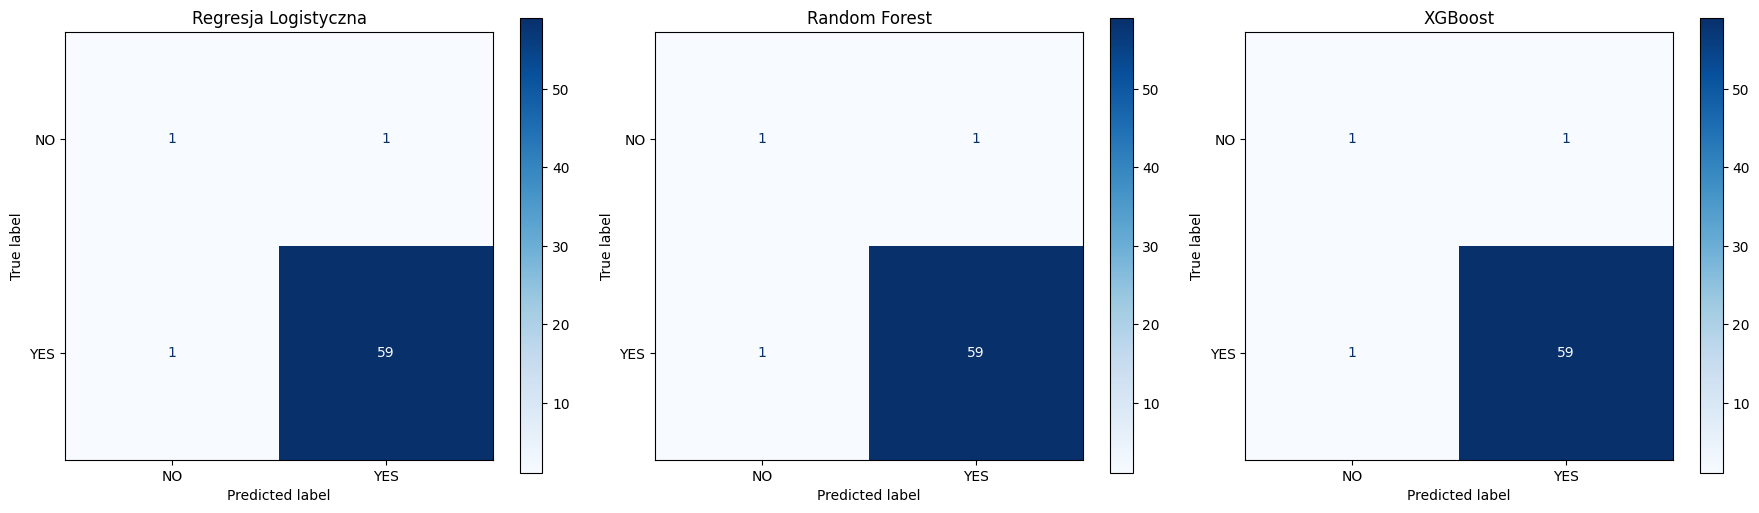

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Lista modeli do porównania
models = [
    ("Regresja Logistyczna", pipeline),
    ("Random Forest", pipeline_rf),
    ("XGBoost", pipeline_xgb)
]

#Pętla przez modele
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models):
    # Trenowanie
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Wyświetlanie wyników
    print(f"--- {name} ---")
    print(f"Dokładność: {accuracy_score(y_test, y_pred):.2f}")

    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NO', 'YES'])
    disp.plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

Regresja Logistyczna - ROC-AUC: 0.9167
Random Forest - ROC-AUC: 0.9667
XGBoost - ROC-AUC: 0.9583


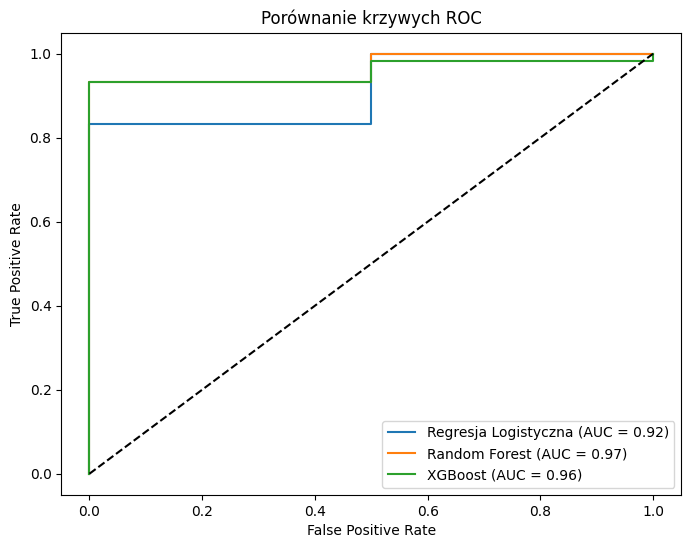

In [96]:
from sklearn.metrics import roc_auc_score, roc_curve

#Lista modeli do porównania
models = [
    ("Regresja Logistyczna", pipeline),
    ("Random Forest", pipeline_rf),
    ("XGBoost", pipeline_xgb)
]

#Porównanie ROC-AUC
plt.figure(figsize=(8, 6))

for name, model in models:
    model.fit(X_train, y_train)

    #prawdopodobieństw klasy 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Obliczanie ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name} - ROC-AUC: {auc:.4f}")

    # Przygotowanie krzywej ROC do wykresu
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

# Wykres ustawienia
plt.plot([0, 1], [0, 1], 'k--') # Linia losowego zgadywania
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Porównanie krzywych ROC')
plt.legend()
plt.show()

#Porównanie modeli

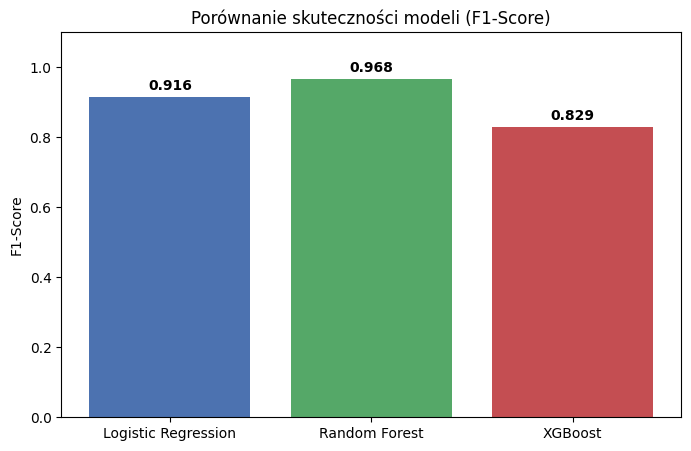

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# 1. Definicja potoków (Pipeline)
# Każdy model ma swój StandardScaler, co jest bardzo bezpieczne
pipelines = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced'))]),
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))]),
    "XGBoost": Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(scale_pos_weight=7, random_state=42))])
    # Uwaga: w XGBoost scale_pos_weight ustaw na stosunek negatywnych do pozytywnych (ok. 270/39 ≈ 7)
}

# 2. Pętla treningowa
results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train) # Pipeline sam przeskaluje dane!
    y_pred = pipe.predict(X_test)
    results[name] = f1_score(y_test, y_pred, average='weighted')
#Aby sprawdzić, czy wynik Logistic Regression nie jest lepsza tylko dlatego, że ma intensywaniejszą sztywność dodaję
results[name] = f1_score(y_test, y_pred, average='macro')

# 3. Wykres słupkowy
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Porównanie skuteczności modeli (F1-Score)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, str(round(v, 3)), ha='center', fontweight='bold')
plt.show()